# UNIVERSIDAD AUTÓNOMA METROPOLITANA UNIDAD IZTPALAPA <br>Licenciatura en Computación <br> Temas Selectos de Bases de Datos
## Proyecto Final
### Integrantes: 

- Alejandro Estrada Basilio (2203043898)
- Mariel Cielo Huerta
- Ricardo Palomino Bravo (2233013059)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [52]:
df = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')

df_inegi = pd.read_excel('INEGI_exporta_17_7_2026_15_49_30_limpio.xlsx')
  

In [55]:
#renombrando columans del df_inegi
df_inegi = df_inegi.rename(columns={
    ' Total': 'Entidad',
    ' Total.1': 'Poblacion'
})

print(df_inegi)

    Unnamed: 0                           Entidad  Poblacion   Hombres  \
0            1                    Aguascalientes    1425607    696683   
1            2                   Baja California    3769020   1900589   
2            3               Baja California Sur     798447    405879   
3            4                          Campeche     928363    456939   
4            5              Coahuila de Zaragoza    3146771   1563669   
5            6                            Colima     731391    360622   
6            7                           Chiapas    5543828   2705947   
7            8                         Chihuahua    3741869   1853822   
8            9                  Ciudad de México    9209944   4404927   
9           10                           Durango    1832650    904866   
10          11                        Guanajuato    6166934   2996454   
11          12                          Guerrero    3540685   1700612   
12          13                           Hidalgo   

In [ ]:
#quedandonos solo con las columnas que nos importan en el dataframe df_inegi
df_inegi = df_inegi[['Entidad', 'Poblacion']]
print(df_inegi)

                             Entidad  Poblacion
0                     Aguascalientes    1425607
1                    Baja California    3769020
2                Baja California Sur     798447
3                           Campeche     928363
4               Coahuila de Zaragoza    3146771
5                             Colima     731391
6                            Chiapas    5543828
7                          Chihuahua    3741869
8                   Ciudad de México    9209944
9                            Durango    1832650
10                        Guanajuato    6166934
11                          Guerrero    3540685
12                           Hidalgo    3082841
13                           Jalisco    8348151
14                            México   16992418
15               Michoacán de Ocampo    4748846
16                           Morelos    1971520
17                           Nayarit    1235456
18                        Nuevo León    5784442
19                            Oaxaca    

In [68]:
df_inegi.head()

,Entidad,Poblacion
0,Aguascalientes,1425607
1,Baja California,3769020
2,Baja California Sur,798447
3,Campeche,928363
4,Coahuila de Zaragoza,3146771


In [66]:
#revisando el nombre de las entidades para ver si coinciden: ##REVISANDO EL DE INEGI
df_inegi['Entidad'].unique()

array([' Aguascalientes', ' Baja California', ' Baja California Sur',
       ' Campeche', ' Coahuila de Zaragoza', ' Colima', ' Chiapas',
       ' Chihuahua', ' Ciudad de México', ' Durango', ' Guanajuato',
       ' Guerrero', ' Hidalgo', ' Jalisco', ' México',
       ' Michoacán de Ocampo', ' Morelos', ' Nayarit', ' Nuevo León',
       ' Oaxaca', ' Puebla', ' Querétaro', ' Quintana Roo',
       ' San Luis Potosí', ' Sinaloa', ' Sonora', ' Tabasco',
       ' Tamaulipas', ' Tlaxcala', ' Veracruz de Ignacio de la Llave',
       ' Yucatán', ' Zacatecas'], dtype=object)

In [67]:
df_copia['Entidad'].unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila de Zaragoza', 'Colima', 'Chiapas',
       'Chihuahua', 'Ciudad de México', 'Durango', 'Guanajuato',
       'Guerrero', 'Hidalgo', 'Jalisco', 'México', 'Michoacán de Ocampo',
       'Morelos', 'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla',
       'Querétaro', 'Quintana Roo', 'San Luis Potosí', 'Sinaloa',
       'Sonora', 'Tabasco', 'Tamaulipas', 'Tlaxcala',
       'Veracruz de Ignacio de la Llave', 'Yucatán', 'Zacatecas'],
      dtype=object)

In [ ]:
#LIMPIANDO DETALLES DE LOS NOMBRES DE LAS ENTIDADES DEL df_entidad: #aqui se elimino un espacio que tenia este estado
df_inegi["Entidad"] = df_inegi["Entidad"].str.strip()

In [73]:
#revisando en cuales nombres no coindicen
estados_inegi = set(df_inegi["Entidad"].str.strip().unique())

estados_delitos = set(df_copia["Entidad"].unique())

estados_inegi - estados_delitos
print(estados_inegi - estados_delitos)

set()


In [ ]:
#construyendo el diccionario

poblacion_estados = {'Aguascalientes':1425607,'Baja California':3769020,'Baja California Sur':798447,'Campeche':928363,
                     'Coahuila de Zaragoza':3146771,'Colima':731391,'Chiapas':5543828,'Chihuahua':3741869,'Ciudad de México':9209944,
                     'Durango':1832650,'Guanajuato':6166934,'Guerrero':3540685,'Hidalgo':3082841,'Jalisco':8348151,'México':16992418,
                     'Michoacán de Ocampo':4748846,'Morelos':1971520,'Nayarit':1235456,'Nuevo León':5784442,'Oaxaca':4132148,'Puebla':6583278,
                     'Querétaro':2368467,'Quintana Roo':1857985,'San Luis Potosí':2822255,'Sinaloa':3026943,'Sonora':2944840,'Tabasco':2402598,
                     'Tamaulipas':3527735,'Tlaxcala':1342977,'Veracruz de Ignacio de la Llave':8062579,'Yucatán':2320898,'Zacatecas':1622138}

In [ ]:
#usando .map()
df_copia["Poblacion"] = df_copia["Entidad"].map(poblacion_estados)


In [60]:
df_inegi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Entidad    32 non-null     object
 1   Poblacion  32 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 644.0+ bytes


In [63]:
#copia del dataset
df_copia = df.copy()

In [4]:
df_copia.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,0,1,0,0,1,0,0,0,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80960 entries, 0 to 80959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Año                     80960 non-null  int64 
 1   Clave_Ent               80960 non-null  int64 
 2   Entidad                 80960 non-null  object
 3   Bien jurídico afectado  80960 non-null  object
 4   Tipo de delito          80960 non-null  object
 5   Subtipo de delito       80960 non-null  object
 6   Modalidad               80960 non-null  object
 7   Sexo                    80960 non-null  object
 8   Rango de edad           80960 non-null  object
 9   Enero                   80960 non-null  int64 
 10  Febrero                 80960 non-null  int64 
 11  Marzo                   80960 non-null  int64 
 12  Abril                   80960 non-null  int64 
 13  Mayo                    80960 non-null  int64 
 14  Junio                   80960 non-null  int64 
 15  Ju

In [7]:
df_copia.tail()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
80955,2025,32,Zacatecas,Libertad personal,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,No identificado,No identificado,0,...,0,0,0,0,2,2,0,0,0,0
80956,2025,32,Zacatecas,El patrimonio,Extorsión,Extorsión,Extorsión,No identificado,No identificado,0,...,2,1,0,0,0,0,1,0,0,2
80957,2025,32,Zacatecas,La sociedad,Corrupción de menores,Corrupción de menores,Corrupción de menores,No identificado,No identificado,1,...,1,0,1,0,1,0,0,0,0,1
80958,2025,32,Zacatecas,La sociedad,Trata de personas,Trata de personas,Trata de personas,No identificado,No identificado,0,...,0,0,2,0,0,0,0,0,0,0
80959,2025,32,Zacatecas,La sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,No identificado,No identificado,0,...,0,0,0,0,0,0,0,0,0,0


## Víctimas por mes en cada entidad a lo largo de 2015-2025

In [8]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
resultado = df_copia.groupby('Entidad')[meses].sum().reset_index()
print(resultado)

                            Entidad  Enero  Febrero  Marzo  Abril   Mayo  \
0                    Aguascalientes   3976     4161   5007   4916   5270   
1                   Baja California  14914    14885  16840  16313  17441   
2               Baja California Sur   2339     2291   2708   2553   2775   
3                          Campeche   1768     1736   2085   1861   1978   
4                           Chiapas   3556     3429   3942   3693   3762   
5                         Chihuahua   8841     9477  10787  10537  12180   
6                  Ciudad de México  15000    15969  17765  16413  17202   
7              Coahuila de Zaragoza   4913     5553   6309   6168   6872   
8                            Colima   2625     2403   2854   2633   2746   
9                           Durango   3719     3912   4361   4169   4792   
10                       Guanajuato  18413    18334  21783  20427  22466   
11                         Guerrero   6585     6319   6932   6786   7432   
12          

In [9]:
df_copia.duplicated().sum() 

np.int64(0)

___

# 1. ¿Cuál fue la alteración de los delitos pre-pandemia, pandemia y post-pandemia?

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
##Reformulación de la pregunta

# ¿La media de la incidencia delictiva mensual cambió significativamente entre el periodo pre-pandemia y pandemia?

## aqui pueden aplicar una prueba t'Student para muestras independientes (o su equivalente no parametrico) para demostrar si el cambio fue real o fruto del azar 

Definimos los periodos de la siguiente manera: 

Pre-pandemia: 2015 - 2019 <br>
Pandemia: 2020 - 2021 <br>
Post-pandemia: 2022 - 2025 <br>

In [10]:
df_p1 = df.copy()

In [11]:
# Total de delitos por año 
df_p1['Total_anual'] = df_p1[meses].sum(axis=1)
totales_por_anio = df_p1.groupby('Año')['Total_anual'].sum().reset_index()

df_p1.head(10)
print(totales_por_anio)

     Año  Total_anual
0   2015       296318
1   2016       292812
2   2017       311565
3   2018       318749
4   2019       346275
5   2020       315570
6   2021       342320
7   2022       367065
8   2023       379169
9   2024       377251
10  2025       362450


In [12]:
# Clasificamos cada año en su periodo correspondiente
def clasificar_periodo(anio):
    if anio <= 2019:
        return 'Pre-pandemia'
    elif anio <= 2021:
        return 'Pandemia'
    else:
        return 'Post-pandemia'

In [13]:
totales_por_anio['Periodo'] = totales_por_anio['Año'].apply(clasificar_periodo)
print(totales_por_anio)

     Año  Total_anual        Periodo
0   2015       296318   Pre-pandemia
1   2016       292812   Pre-pandemia
2   2017       311565   Pre-pandemia
3   2018       318749   Pre-pandemia
4   2019       346275   Pre-pandemia
5   2020       315570       Pandemia
6   2021       342320       Pandemia
7   2022       367065  Post-pandemia
8   2023       379169  Post-pandemia
9   2024       377251  Post-pandemia
10  2025       362450  Post-pandemia


#### **La variación porcentual mide el aumento o disminución de un valor respecto a su punto de partida en términos de porcentaje.**

*Variación Porcentual = (Valor Final - Valor Inicial) / Valor Inicial * 100*

In [14]:
# Promedio anual de delitos por periodo
promedio_periodo = totales_por_anio.groupby('Periodo')['Total_anual'].mean().reindex(
    ['Pre-pandemia', 'Pandemia', 'Post-pandemia'])
print(promedio_periodo)

# Variación porcentual entre periodos
variacion_pandemia = (promedio_periodo['Pandemia'] - promedio_periodo['Pre-pandemia']) / promedio_periodo['Pre-pandemia'] * 100
variacion_post = (promedio_periodo['Post-pandemia'] - promedio_periodo['Pandemia']) / promedio_periodo['Pandemia'] * 100

print(f"\nVariación pre-pandemia -> pandemia: {variacion_pandemia:.2f}%")
print(f"Variación pandemia -> post-pandemia: {variacion_post:.2f}%")

Periodo
Pre-pandemia     313143.80
Pandemia         328945.00
Post-pandemia    371483.75
Name: Total_anual, dtype: float64

Variación pre-pandemia -> pandemia: 5.05%
Variación pandemia -> post-pandemia: 12.93%


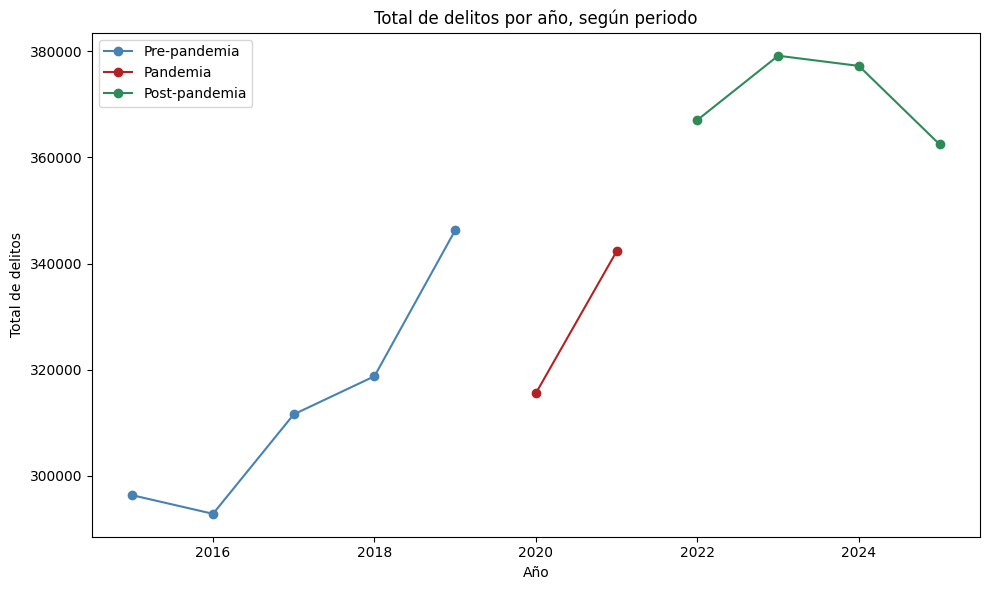

In [15]:
# Gráfica de línea por año, coloreada por periodo
plt.figure(figsize=(10, 6))
colores = {'Pre-pandemia': 'steelblue', 'Pandemia': 'firebrick', 'Post-pandemia': 'seagreen'}
for periodo in ['Pre-pandemia', 'Pandemia', 'Post-pandemia']:
    subset = totales_por_anio[totales_por_anio['Periodo'] == periodo]
    plt.plot(subset['Año'], subset['Total_anual'], marker='o', label=periodo, color=colores[periodo])

plt.title('Total de delitos por año, según periodo')
plt.xlabel('Año')
plt.ylabel('Total de delitos')
plt.legend()
plt.tight_layout()
plt.show()

___

# !!!!!!!!!!!!!!!!!!!!!
# ------- Reformulacion de pregunta #
## para contestarla bien primero hay que:
## Normalizar los datos calculando la tasa de delitos por cada 100,000 habitantes
## primero busca los datos de población por estado el INEGI para los años de su estudio. La formula que deben aplicar para cada estado/estado
## Tasa = (total de delitos / poblacion del estado) x (100,000)

# NOTA:
## TODAS SUS PRUEBAS ESTADISTICAS (ANOVA, REGRESION, ETC.) DEBEN HACERSE CON ESTA TASA NORMALIZADA, NO CON NUMEROS ABSOLUTOS
# 4- ¿Cuál es el año con mayor indice delictivo?

In [16]:
# Agrupa los datos por entidad y suma el total de incidencias de cada mes para cada una
resultado=df_copia.groupby('Año')[meses].sum().reset_index()
#convierte el resultado en un dataframe
res_df = pd.DataFrame(resultado)
print(res_df)
res_df.describe()

#sumar de enero a diciembre de cada año
res_df['Total'] = (res_df['Enero'] + res_df['Febrero'] + res_df['Marzo'] + res_df['Abril'] + res_df['Mayo'] + res_df['Junio'] + res_df['Julio'] +
               res_df['Agosto'] + res_df['Septiembre'] + res_df['Octubre'] + res_df['Noviembre'] + res_df['Diciembre'])

print("\n")
print(res_df['Total'])



#comparación de años:

#comparación de cifras sumadas de cada año:
print("\n")
print(f"El valor máximo es: {res_df['Total'].max()}")

#obtención de año:
print("\n")
print(f"El año con el valor máximo es: {res_df.loc[res_df['Total'].idxmax(), "Año"]}")

#.loc() sirve para seleccionar filas y columnas segun una etiqueta

     Año  Enero  Febrero  Marzo  Abril   Mayo  Junio  Julio  Agosto  \
0   2015  21995    22736  24969  25468  26790  25285  24813   25460   
1   2016  20909    23239  24794  25787  27854  25273  23664   23479   
2   2017  23948    22613  26275  25474  28783  27771  25308   26980   
3   2018  22859    23495  27084  27643  29242  27366  27643   27380   
4   2019  25204    26567  29897  28858  31782  30295  29217   30183   
5   2020  25993    28101  29993  22752  21637  24863  26144   26966   
6   2021  24568    24911  31101  30355  31550  28834  28225   28000   
7   2022  26817    25618  31679  31816  35281  32647  29972   31341   
8   2023  29617    28693  34640  31212  33598  35445  31504   31168   
9   2024  29104    30164  32438  33677  37012  32457  30645   30168   
10  2025  27792    28810  33146  30760  32197  29731  29821   29455   

    Septiembre  Octubre  Noviembre  Diciembre  
0        25378    25856      24142      23426  
1        24922    25052      23375      24464  
2  

# 3. ¿Cuál es el delito más común experimentado por las victimas?

*Transformamos una copia del dataset para que podamos trabajar adecuadamente, luego transformaremos todas las columnas correspondientes a los meses en una nueva columna que muestra los meses y cada mes se vuelva una fila.*

In [17]:
#Realizamos una copia del dataframe por cada pregunta
df_p3 = df.copy()

# Identificamos el resto de las columnas que se van a quedar intactas como Año, Entidad, etc.
columnas_fijas = [col for col in df.columns if col not in meses]

# Aplicamos pd.melt() para transformar las columnas de mes en filas
df_limpio_p3 = pd.melt(
    df_p3, 
    id_vars = columnas_fijas,  # Las columnas que no se mueven
    value_vars = meses,        # Las columnas que se van a convertir en filas
    var_name = 'Mes',          # El nombre de la nueva columna que guardará los meses
    value_name = 'Total_Victimas' # El nombre de la nueva columna que guardará los conteos numéricos
)

# 5. Visualizamos el resultado
df_limpio_p3.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Mes,Total_Victimas
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),Enero,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),Enero,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),Enero,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),Enero,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),Enero,0


In [18]:
# Agrupamos por 'Tipo de delito' y sumamos todas las víctimas de todos los años, meses y estados
delitos_agrupados = df_limpio_p3.groupby('Tipo de delito')['Total_Victimas'].sum()

# Ordenamos los resultados de mayor a menor 
delitos_top = delitos_agrupados.sort_values(ascending=False)

# Lo convertimos a un DataFrame para que se vea como una tabla bonita y mostramos el Top 10
tabla_top_10 = delitos_top.head(10).reset_index()

# Imprimimos la tabla
print("Los delitos más comunes experimentados por las victimas son:")
tabla_top_10


Los delitos más comunes experimentados por las victimas son:


,Tipo de delito,Total_Victimas
0,Lesiones,2568337
1,Homicidio,518338
2,Otros delitos que atentan contra la libertad p...,260265
3,Otros delitos que atentan contra la vida y la ...,124707
4,Extorsión,96026
5,Otros delitos contra la sociedad,70368
6,Corrupción de menores,30175
7,Secuestro,12327
8,Feminicidio,9166
9,Trata de personas,9019


C:\Users\cbi22\AppData\Local\Temp\ipykernel_27016\3759639872.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=top_5.values, y=top_5.index, palette='viridis')


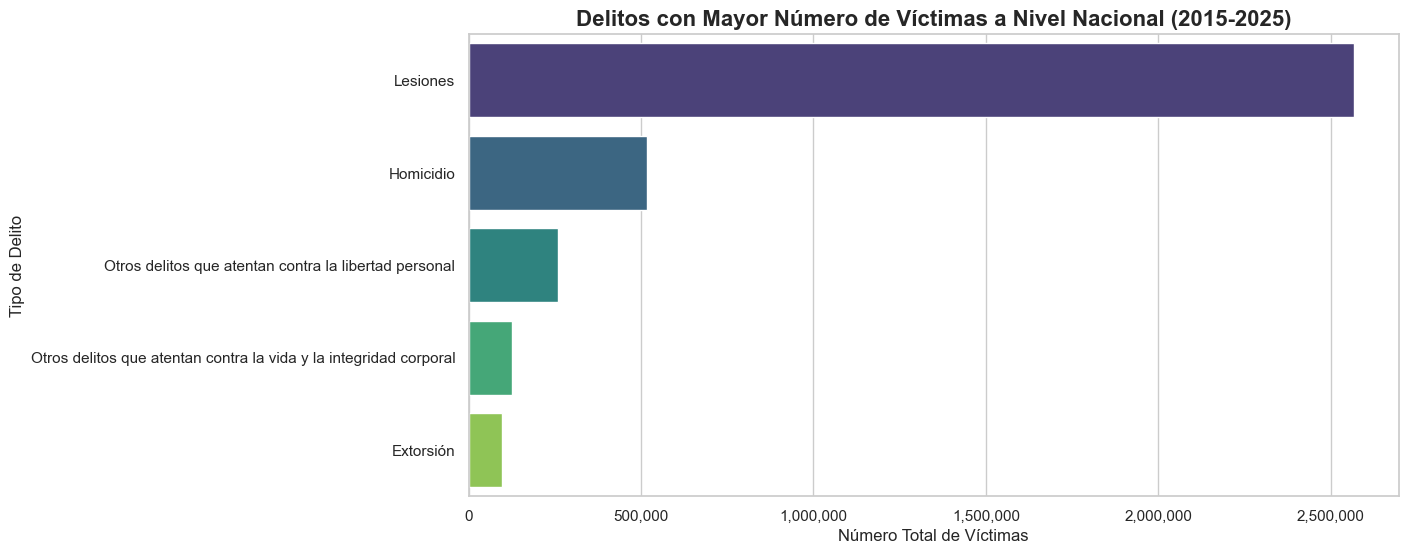

In [19]:
# Configuramos el estilo y tamaño del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Tomamos solo el Top 5 para que la gráfica no se sature
top_5 = delitos_top.head(5)

# Creamos el gráfico de barras horizontales
grafico = sns.barplot(x=top_5.values, y=top_5.index, palette='viridis')

# Ponemos los títulos
plt.title('Delitos con Mayor Número de Víctimas a Nivel Nacional (2015-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Número Total de Víctimas', fontsize=12)
plt.ylabel('Tipo de Delito', fontsize=12)

# Formateamos los números del eje X para que tengan comas (ej. 1,000,000)
grafico.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.show()

### *Observemos además: ¿Los dos delitos más cometidos a víctimas son accidentales o intencionales?*

* ***Delito Doloso***: aquel que se comete con plena intención, conocimiento y voluntad.

* ***Delito Culposo***: aquel que al cometerse no existe la intención de causar un daño, pero el resultado se produce debido a negligencia, imprudencia, impericia o inobservancia de las leyes.

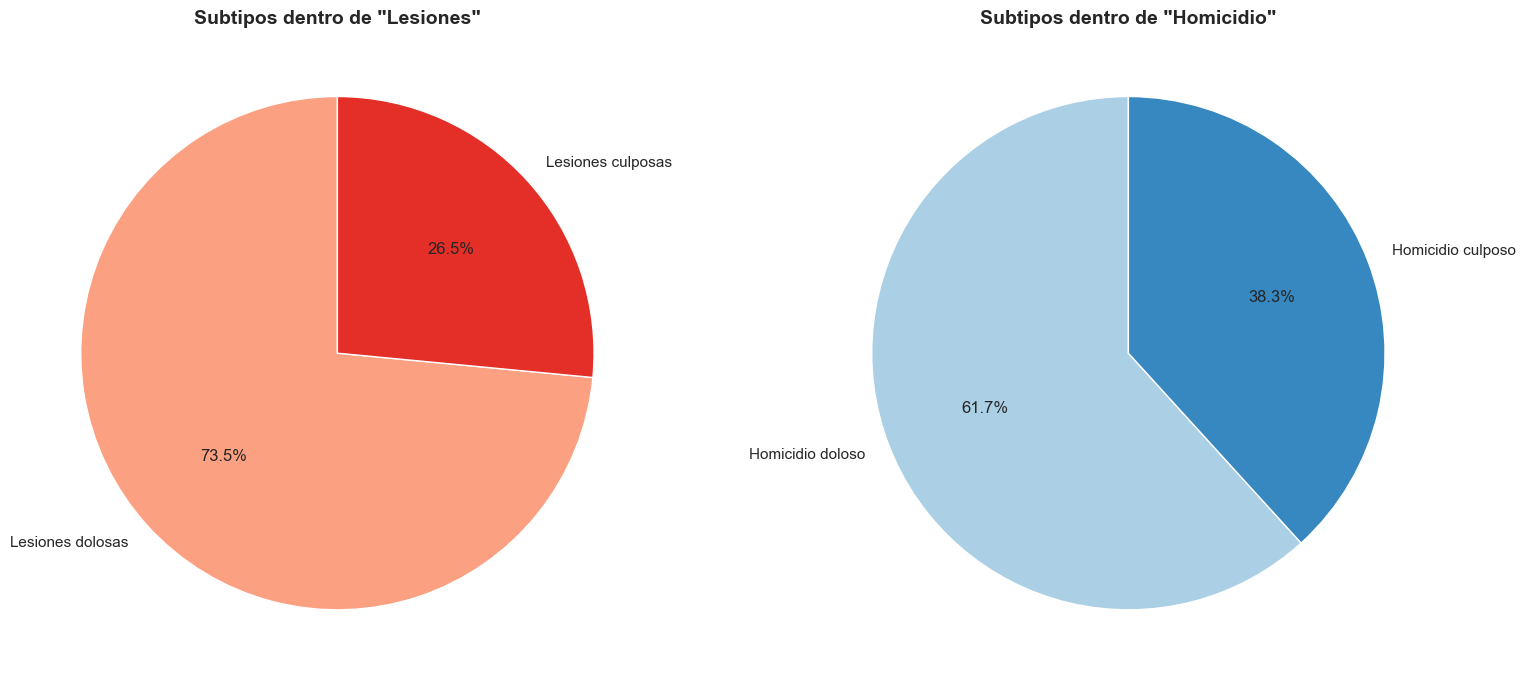

In [20]:
# Proporciones por Subtipo de Delito
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: LESIONES ---
# Filtramos solo las Lesiones y agrupamos por Subtipo
df_lesiones = df_limpio_p3[df_limpio_p3['Tipo de delito'] == 'Lesiones']
sub_lesiones = df_lesiones.groupby('Subtipo de delito')['Total_Victimas'].sum().sort_values(ascending=False)

# Dibujamos el pastel (Usamos una paleta de tonos Rojos)
axes[0].pie(sub_lesiones, labels=sub_lesiones.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("Reds", len(sub_lesiones)))
axes[0].set_title('Subtipos dentro de "Lesiones"', fontweight='bold', fontsize=14)

# --- GRÁFICO 2: HOMICIDIO ---
# Filtramos solo los Homicidios y agrupamos por Subtipo
df_homicidio = df_limpio_p3[df_limpio_p3['Tipo de delito'] == 'Homicidio']
sub_homicidio = df_homicidio.groupby('Subtipo de delito')['Total_Victimas'].sum().sort_values(ascending=False)

# Dibujamos el pastel (Usamos una paleta de tonos Azules)
axes[1].pie(sub_homicidio, labels=sub_homicidio.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("Blues", len(sub_homicidio)))
axes[1].set_title('Subtipos dentro de "Homicidio"', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

#### *Los dos tipos de delito más comunes perpetrados a las victimas **son en su mayoría premeditados o hechos con saña, alevosía y/o ventaja.***

_____

# 4. ¿Cuál es el estado con más victimas desde 2015 hasta 2025?

In [21]:
df_p4 = df.copy()
resultado = df_p4.groupby('Entidad')[meses].sum().reset_index()

In [22]:
# Sumamos los 12 meses para obtener el total de incidencias por estado
resultado['Total'] = resultado[meses].sum(axis=1) #axis = 1 suma horizontalmente 

# Ordenamos de mayor a menor
resultado_ordenado = resultado.sort_values('Total', ascending=False) #(ascending = false) = descending
print(resultado_ordenado[['Entidad', 'Total']])

# El estado con más incidencias que será el que esté en primer lugar, peuesto que ya ordenamos 
estado_max = resultado_ordenado.iloc[0] 
print(f"\nEl estado con más incidencias delictivas es {estado_max['Entidad']} con {estado_max['Total']} víctimas registradas.")

                            Entidad   Total
16                           México  871069
10                       Guanajuato  245881
1                   Baja California  203057
13                          Jalisco  202384
6                  Ciudad de México  198022
18                       Nuevo León  172920
29  Veracruz de Ignacio de la Llave  142418
5                         Chihuahua  131416
14              Michoacán de Ocampo  127493
20                           Puebla  107887
21                        Querétaro   99009
12                          Hidalgo   98245
19                           Oaxaca   93525
26                          Tabasco   86750
24                          Sinaloa   84260
27                       Tamaulipas   81365
11                         Guerrero   79323
22                     Quintana Roo   74134
15                          Morelos   73945
7              Coahuila de Zaragoza   73687
23                  San Luis Potosí   68837
25                           Son

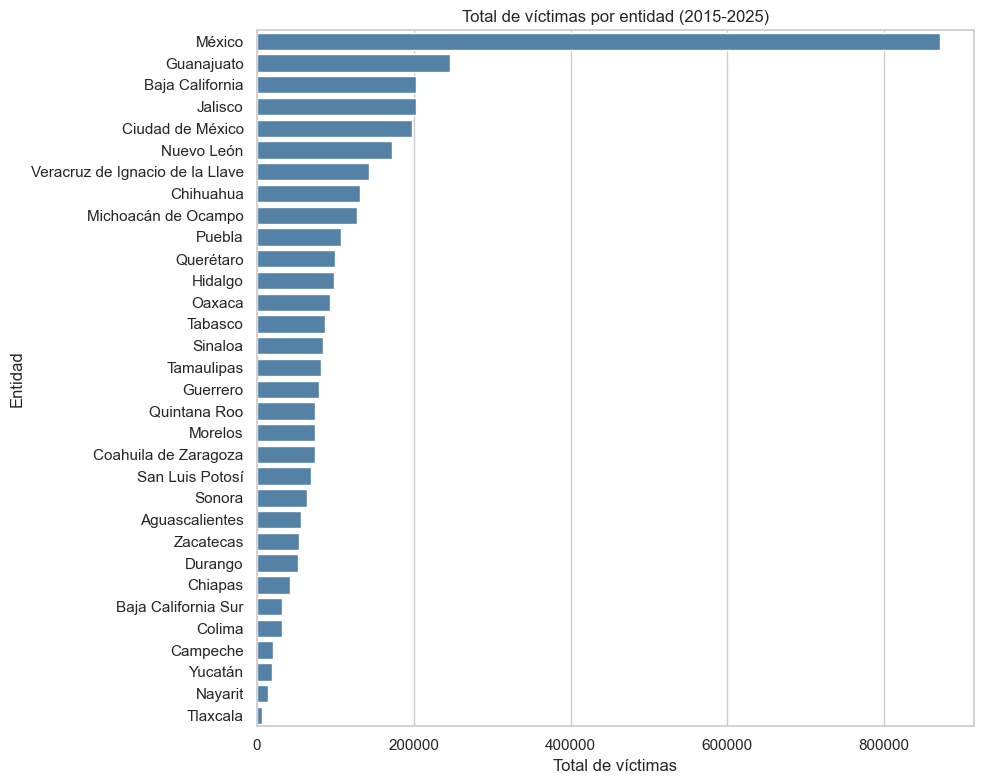

In [23]:
# Gráfica de barras para visualizar el ranking
plt.figure(figsize=(10, 8))
sns.barplot(data=resultado_ordenado, x='Total', y='Entidad', color='steelblue')
plt.title('Total de víctimas por entidad (2015-2025)')
plt.xlabel('Total de víctimas')
plt.ylabel('Entidad')
plt.tight_layout()

_____

# 6- ¿Qué estados tienen más víctimas del sexo masculino y qué estados del sexo femenino?

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
## Reformulación de la pregunta

# Pueden plantear si la proporción o el promedio de víctimas masculinas V.S femeninas difiere significativamente mediante pruebas estadísticas de comparación de dos grupos

In [26]:
#filtrado para que ya no aparezca "No identidicado"
df_filtrado = df_copia[df_copia['Sexo'] != 'No identificado']

# Agrupa los datos por entidad y suma el total de incidencias de cada mes para cada una
resultado = df_filtrado.groupby(['Entidad', 'Sexo'])[meses].sum().reset_index()

print(resultado)




#sumar de enero a diciembre de cada año
resultado['Total'] = (resultado['Enero'] +  resultado['Febrero'] + resultado['Marzo'] + resultado['Abril'] + resultado['Mayo'] + resultado['Junio'] +
             resultado['Julio'] + resultado['Agosto'] + resultado['Septiembre'] + resultado['Octubre'] + resultado['Noviembre'] + resultado['Diciembre'])

print("\n")
print(resultado['Total'])




                            Entidad    Sexo  Enero  Febrero  Marzo  Abril  \
0                    Aguascalientes  Hombre    286      283    303    320   
1                    Aguascalientes   Mujer     92      113    107    105   
2                   Baja California  Hombre   8352     8264   9365   9207   
3                   Baja California   Mujer   5100     5459   6019   5815   
4               Baja California Sur  Hombre   1308     1227   1426   1381   
..                              ...     ...    ...      ...    ...    ...   
59  Veracruz de Ignacio de la Llave   Mujer   3079     3446   4067   3984   
60                          Yucatán  Hombre   1150     1212   1375   1246   
61                          Yucatán   Mujer    401      295    363    460   
62                        Zacatecas  Hombre   2811     2655   2954   2820   
63                        Zacatecas   Mujer   1287     1177   1453   1467   

    Mayo  Junio  Julio  Agosto  Septiembre  Octubre  Noviembre  Diciembre  

In [27]:
#separando datos solamente de 'Hombres'

print("\n")
hombres = resultado[resultado['Sexo'] == 'Hombre']
hombres['Total'].max() #devuelve el valor maximo de esa fila
hombres.loc[hombres['Total'].idxmax(), 'Entidad'] #devuelve el estado
print(f"El numero de víctimas de hombres es: {hombres['Total'].max()}")
print("\n")
print(f"El estado con más víctimas de hombres es: {hombres.loc[hombres['Total'].idxmax(), 'Entidad']}")



#separando datos solamente de ' Mujeres'

print("\n")
mujeres = resultado[resultado['Sexo'] == 'Mujer']
mujeres['Total'].max() #devuelve el valor maximo de esa fila
mujeres.loc[mujeres['Total'].idxmax(), 'Entidad'] #devuelve el estado
print(f"El número de víctimas de mujeres es: {mujeres['Total'].max()}")
print("\n")
print(f"El estado con más muertes de mujeres es: {mujeres.loc[mujeres['Total'].idxmax(), 'Entidad']}")








El numero de víctimas de hombres es: 364882


El estado con más víctimas de hombres es: México


El número de víctimas de mujeres es: 288029


El estado con más muertes de mujeres es: México


In [28]:
#el estado donde hay más incidencias de hombres y mujeres es en el estado de México

df_copia.value_counts('Entidad')

Entidad
Aguascalientes                     2530
Baja California                    2530
Baja California Sur                2530
Campeche                           2530
Chiapas                            2530
Chihuahua                          2530
Ciudad de México                   2530
Coahuila de Zaragoza               2530
Colima                             2530
Durango                            2530
Guanajuato                         2530
Guerrero                           2530
Hidalgo                            2530
Jalisco                            2530
Michoacán de Ocampo                2530
Morelos                            2530
México                             2530
Nayarit                            2530
Nuevo León                         2530
Oaxaca                             2530
Puebla                             2530
Querétaro                          2530
Quintana Roo                       2530
San Luis Potosí                    2530
Sinaloa                         

# 6. ¿Hay algún mes en donde los delitos contra las victimas sea mayor? 

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
##PREGUNTA REFORMULADA:
# ¿Existe una diferencia estadísticamente significativa en la media de homicidios entre los diferentes meses del año?

##esto se responde con un ANOVA o pruebas de comparación múltiples grupos, evaluando primero la normalidad

*A continuación mostramos el pico máximo de los delitos más comunes asociados al mes en donde historicamente hubo más ocurrencias de dichos delitos*


In [24]:
# Agrupamos sumando por año para tener el total nacional mensual de TODOS los delitos a la vez
nacional_todos = df_limpio_p3.groupby(['Año', 'Mes', 'Tipo de delito'])['Total_Victimas'].sum().reset_index()

# Calculamos el PROMEDIO histórico de cada mes para cada delito
promedio_delitos = nacional_todos.groupby(['Tipo de delito', 'Mes'])['Total_Victimas'].mean().reset_index()

#  Buscamos el índice del valor máximo para cada delito
# .idxmax() encuentra en qué fila está el valor más alto (el pico) de cada grupo
indices_picos = promedio_delitos.groupby('Tipo de delito')['Total_Victimas'].idxmax()

# Usamos esos índices para filtrar nuestra tabla y quedarnos SOLO con los meses pico
meses_pico = promedio_delitos.loc[indices_picos]

# Ordenamos de mayor a menor impacto y renombramos la columna para que sea clara
meses_pico = meses_pico.sort_values(by='Total_Victimas', ascending=False)
meses_pico.rename(columns={'Total_Victimas': 'Promedio_Maximo_Mensual'}, inplace=True)



#  Filtramos aquellos que tienen 0 víctimas (delitos que no ocurren) y mostramos el Top 15
meses_pico = meses_pico[meses_pico['Promedio_Maximo_Mensual'] > 0]
meses_pico.head(15).reset_index(drop=True)
print("-> Notamos que el mes de MAYO, es el mes donde más ocurrencias hay de 4 tipos de delito")
print("-> Además MAYO, es el més donde ocurren los dos delitos más comunes")


-> Notamos que el mes de MAYO, es el mes donde más ocurrencias hay de 4 tipos de delito
-> Además MAYO, es el més donde ocurren los dos delitos más comunes


*Como pudimos ver, el mes de MAYO tiene el lugar como el mes donde 3 de los delitos más comunes presentan máximos históricos a lo largo del periodo del tiempo reportado. ¿Y si observamos el comportamiento general de los delitos en los meses de MAYO desde 2015 hasta 2025?*

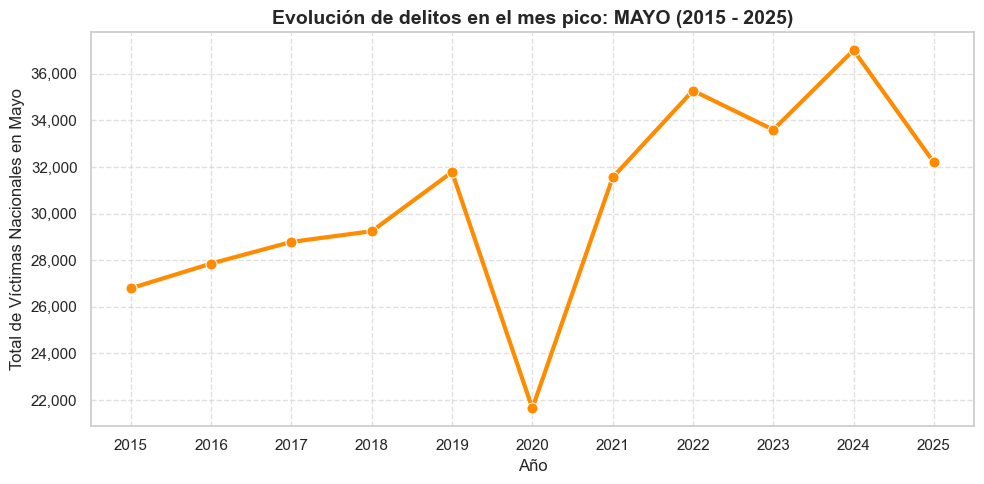

In [ ]:
# Tendencia Histórica de los meses de Mayo
# Filtramos el dataset para quedarnos SOLAMENTE con los meses de Mayo
df_mayo = df_limpio_p3[df_limpio_p3['Mes'] == 'Mayo']

# Sumamos el total de todos los delitos a nivel nacional agrupado por Año
mayo_historico = df_mayo.groupby('Año')['Total_Victimas'].sum().reset_index()

# Graficamos la tendencia en el tiempo
plt.figure(figsize=(10, 5))
grafico_mayo = sns.lineplot(data=mayo_historico, x='Año', y='Total_Victimas', 
                            marker='o', color='darkorange', linewidth=3, markersize=8)

plt.title('Evolución de delitos en el mes pico: MAYO (2015 - 2025)', fontweight='bold', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Víctimas Nacionales en Mayo', fontsize=12)

# Formateo visual (Poner comas al eje Y, y forzar que el eje X muestre todos los años)
grafico_mayo.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))
plt.xticks(mayo_historico['Año']) # Muestra 2015, 2016, 2017... sin decimales

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **¿Por qué los delitos relacionados con agresiones físicas son perpetrados mayormente a este mes?**